In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:

#extracting data from csv file using pandas library
df=pd.read_csv("E:\\Projects\\InnoBytes\\Amazon Sale Report.csv",encoding='latin1')
#display the first 5 rows of dataset
print(df.head())
#display information about the dataset
print(df.info())



   index             Order ID      Date                        Status  \
0      0  405-8078784-5731545  04-30-22                     Cancelled   
1      1  171-9198151-1101146  04-30-22  Shipped - Delivered to Buyer   
2      2  404-0687676-7273146  04-30-22                       Shipped   
3      3  403-9615377-8133951  04-30-22                     Cancelled   
4      4  407-1069790-7240320  04-30-22                       Shipped   

  Fulfilment Sales Channel ship-service-level  Category Size Courier Status  \
0   Merchant     Amazon.in           Standard   T-shirt    S     On the Way   
1   Merchant     Amazon.in           Standard     Shirt  3XL        Shipped   
2     Amazon     Amazon.in          Expedited     Shirt   XL        Shipped   
3   Merchant     Amazon.in           Standard   Blazzer    L     On the Way   
4     Amazon     Amazon.in          Expedited  Trousers  3XL        Shipped   

   ...  currency  Amount    ship-city   ship-state ship-postal-code  \
0  ...       IN

In [4]:

#display column names
print(df.columns)


Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Category', 'Size', 'Courier Status', 'Qty',
       'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code',
       'ship-country', 'B2B', 'fulfilled-by', 'New', 'PendingS'],
      dtype='object')


In [5]:
#data cleaning
#converting date column to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%y',errors='coerce')
print(df['Date'])
#drop duplicates
df.drop_duplicates(inplace=True)
print(df)


0        2022-04-30
1        2022-04-30
2        2022-04-30
3        2022-04-30
4        2022-04-30
            ...    
128971   2022-05-31
128972   2022-05-31
128973   2022-05-31
128974   2022-05-31
128975   2022-05-31
Name: Date, Length: 128976, dtype: datetime64[ns]
         index             Order ID       Date                        Status  \
0            0  405-8078784-5731545 2022-04-30                     Cancelled   
1            1  171-9198151-1101146 2022-04-30  Shipped - Delivered to Buyer   
2            2  404-0687676-7273146 2022-04-30                       Shipped   
3            3  403-9615377-8133951 2022-04-30                     Cancelled   
4            4  407-1069790-7240320 2022-04-30                       Shipped   
...        ...                  ...        ...                           ...   
128971  128970  406-6001380-7673107 2022-05-31                       Shipped   
128972  128971  402-9551604-7544318 2022-05-31                       Shipped   
128973  12

In [6]:
# Drop unnecessary columns like 'index', 'New', and 'PendingS'
df.drop(columns=['index', 'New', 'PendingS'], inplace=True)
#Drop null values
df.dropna(subset=['Amount', 'ship-city', 'ship-state', 'Category'], inplace=True)
print(df)


                   Order ID       Date                        Status  \
0       405-8078784-5731545 2022-04-30                     Cancelled   
1       171-9198151-1101146 2022-04-30  Shipped - Delivered to Buyer   
2       404-0687676-7273146 2022-04-30                       Shipped   
3       403-9615377-8133951 2022-04-30                     Cancelled   
4       407-1069790-7240320 2022-04-30                       Shipped   
...                     ...        ...                           ...   
128971  406-6001380-7673107 2022-05-31                       Shipped   
128972  402-9551604-7544318 2022-05-31                       Shipped   
128973  407-9547469-3152358 2022-05-31                       Shipped   
128974  402-6184140-0545956 2022-05-31                       Shipped   
128975  408-7436540-8728312 2022-05-31                       Shipped   

       Fulfilment Sales Channel ship-service-level  Category Size  \
0        Merchant     Amazon.in           Standard   T-shirt    S 

In [7]:
df.rename(columns={
    'ship-city': 'City',
    'ship-state': 'State',
    'ship-country': 'Country',
    'Qty': 'Quantity',
}, inplace=True)


In [8]:
df.head()


,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Quantity,currency,Amount,City,State,ship-postal-code,Country,B2B,fulfilled-by
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN


<Axes: title={'center': 'Monthly Sales Trend'}, xlabel='Date'>

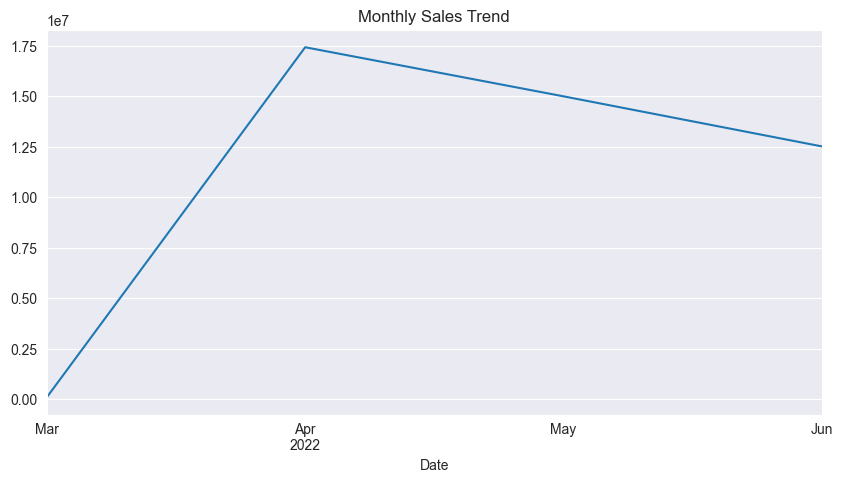

In [9]:
monthly_sales = df.groupby(df['Date'].dt.to_period("M"))['Amount'].sum()
monthly_sales.plot(kind='line', title="Monthly Sales Trend", figsize=(10,5))


C:\Users\DELL\AppData\Local\Temp\ipykernel_14500\958332844.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


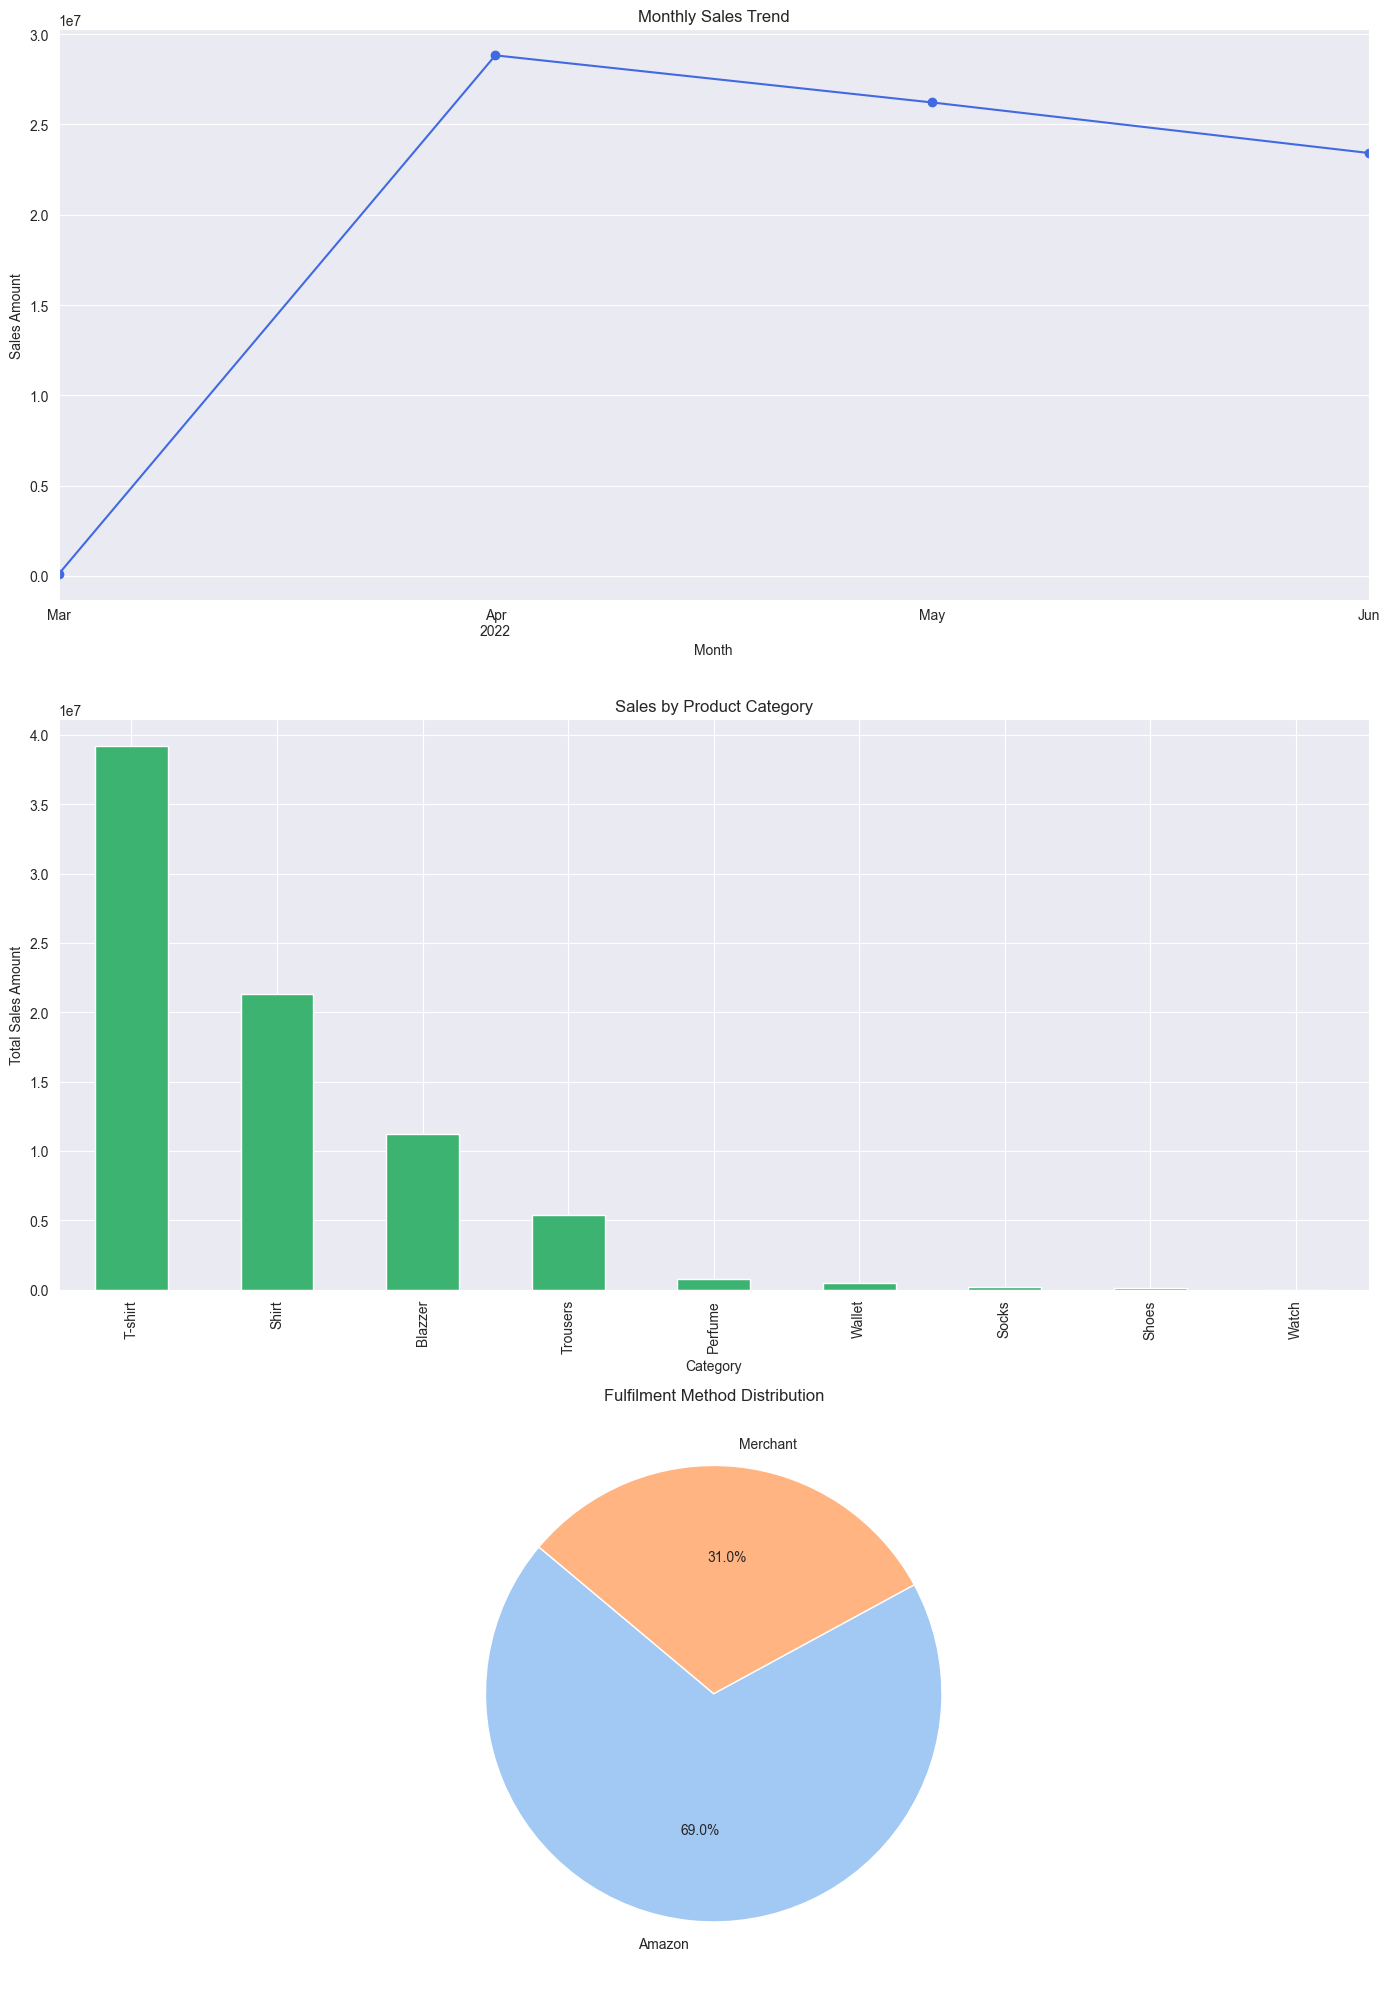

In [10]:
# 1. Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load the dataset
file_path = "Amazon Sale Report.csv"  # Update path if needed
df = pd.read_csv('Amazon Sale Report.csv', encoding='ISO-8859-1')

# 3. Clean and preprocess the data
df.drop(columns=['index', 'New', 'PendingS'], inplace=True, errors='ignore')
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df.dropna(subset=['Date', 'Amount', 'ship-city', 'ship-state', 'Category'], inplace=True)
df.rename(columns={
    'ship-city': 'City',
    'ship-state': 'State',
    'ship-country': 'Country',
    'Qty': 'Quantity'
}, inplace=True)

# 4. Create a Month column for trend analysis
df['Month'] = df['Date'].dt.to_period('M')

# 5. Generate data summaries for plotting
monthly_sales = df.groupby('Month')['Amount'].sum()
product_sales = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)
fulfillment_counts = df['Fulfilment'].value_counts()

# 6. Plotting visualizations
fig, axs = plt.subplots(3, 1, figsize=(14, 20))

# Monthly Sales Trend
monthly_sales.plot(kind='line', ax=axs[0], marker='o', color='royalblue')
axs[0].set_title('Monthly Sales Trend')
axs[0].set_xlabel('Month')
axs[0].set_ylabel('Sales Amount')
axs[0].grid(True)

# Product Category Sales
product_sales.plot(kind='bar', ax=axs[1], color='mediumseagreen')
axs[1].set_title('Sales by Product Category')
axs[1].set_xlabel('Category')
axs[1].set_ylabel('Total Sales Amount')

# Fulfilment Method Distribution
axs[2].pie(fulfillment_counts, labels=fulfillment_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axs[2].set_title('Fulfilment Method Distribution')

plt.tight_layout()
plt.show()


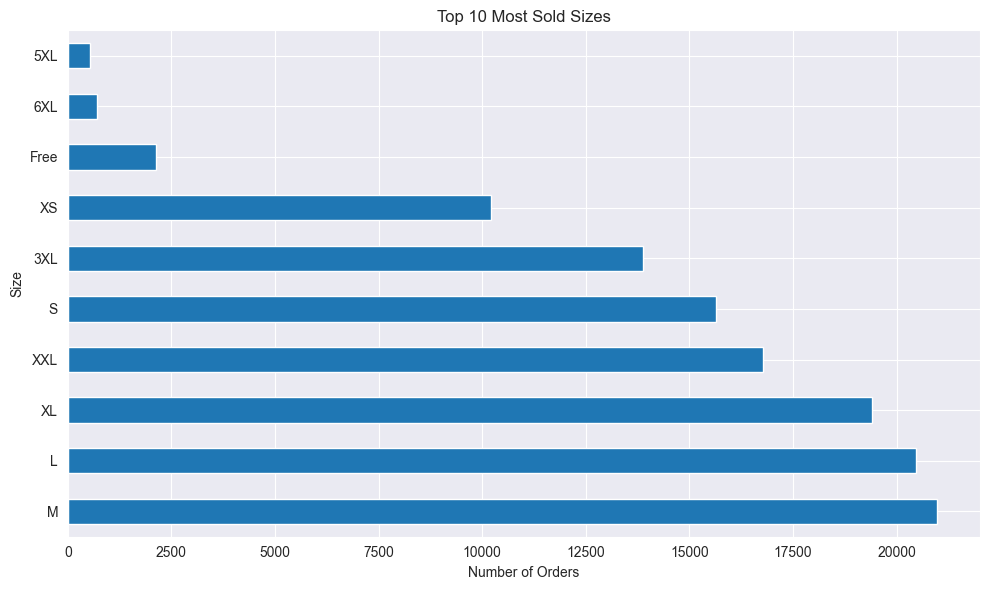

In [11]:
#Most Sold sizes
size_counts = df['Size'].value_counts().head(10)
size_counts.plot(kind='barh', title='Top 10 Most Sold Sizes', figsize=(10, 6))
plt.xlabel('Number of Orders')
plt.ylabel('Size')
plt.tight_layout()
plt.show()


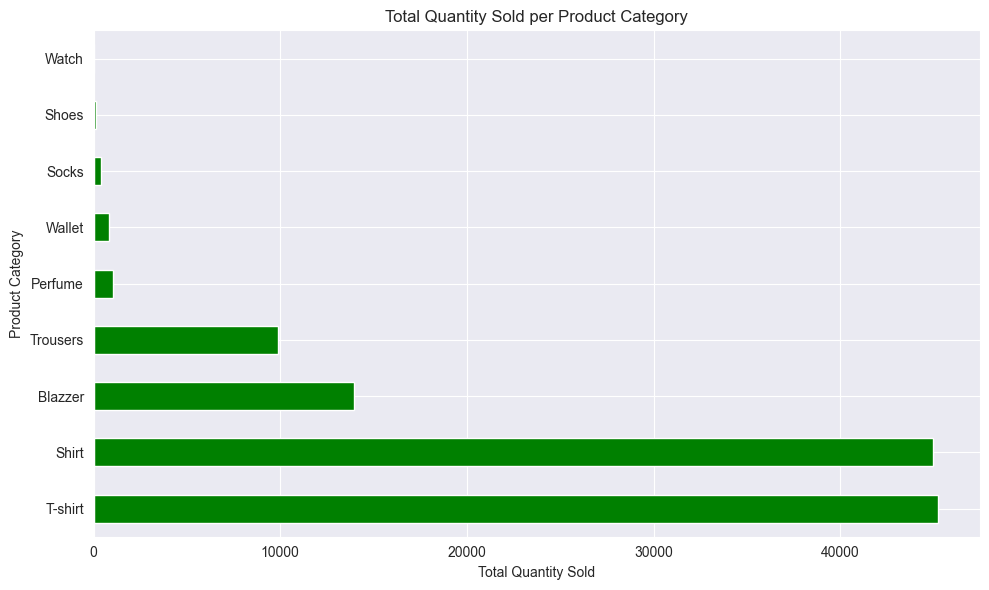

In [12]:
#Total Quantity Sold per category
quantity_by_category = df.groupby('Category')['Quantity'].sum().sort_values(ascending=False)
quantity_by_category.plot(kind='barh', title='Total Quantity Sold per Product Category', figsize=(10, 6), color='green')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_14500\1734190482.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_state.values, y=sales_by_state.index, palette='mako')


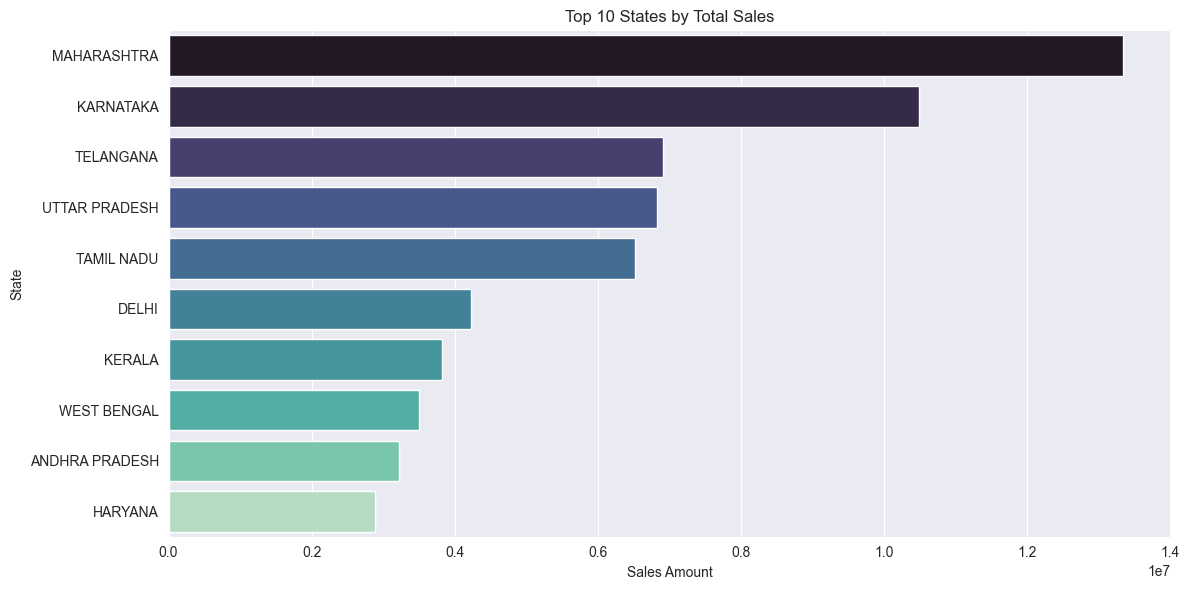

In [13]:
#Top 10 states by total sales
import matplotlib.pyplot as plt
import seaborn as sns

sales_by_state = df.groupby('State')['Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=sales_by_state.values, y=sales_by_state.index, palette='mako')
plt.title('Top 10 States by Total Sales')
plt.xlabel('Sales Amount')
plt.ylabel('State')
plt.tight_layout()
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_14500\1628773980.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_city.values, y=sales_by_city.index, palette='rocket')


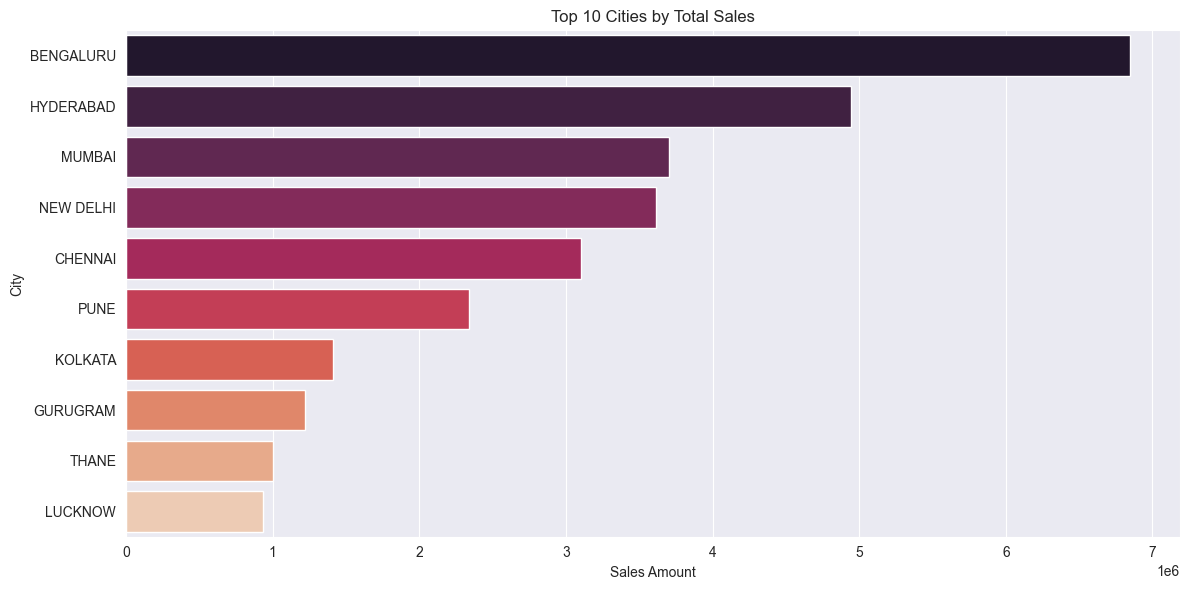

In [14]:
#Top 10 cities by total sales
sales_by_city = df.groupby('City')['Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=sales_by_city.values, y=sales_by_city.index, palette='rocket')
plt.title('Top 10 Cities by Total Sales')
plt.xlabel('Sales Amount')
plt.ylabel('City')
plt.tight_layout()
plt.show()


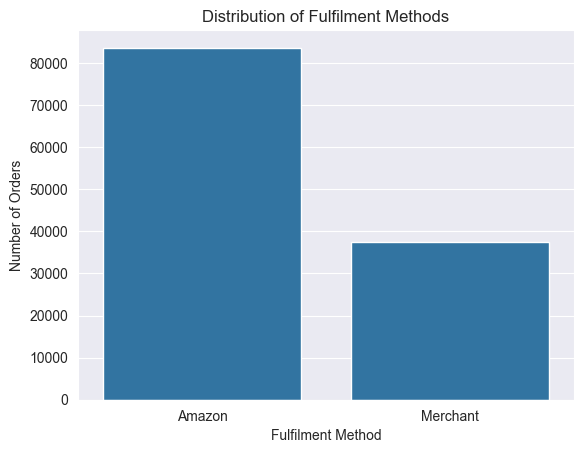

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
df['Fulfilment'].value_counts()

sns.countplot(data=df, x='Fulfilment', order=df['Fulfilment'].value_counts().index)
plt.title("Distribution of Fulfilment Methods")
plt.xlabel("Fulfilment Method")
plt.ylabel("Number of Orders")
plt.show()


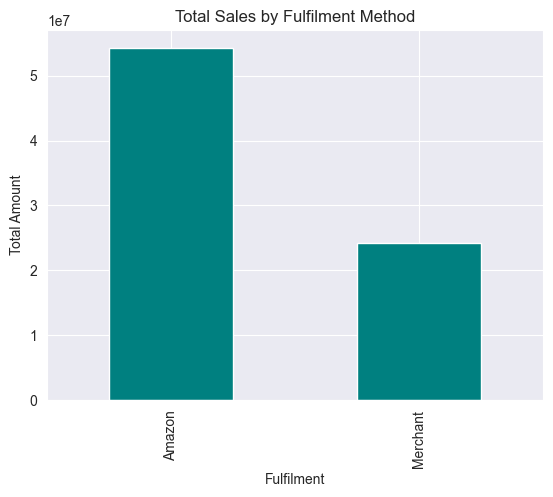

In [16]:
fulfillment_sales = df.groupby('Fulfilment')['Amount'].sum().sort_values(ascending=False)
fulfillment_sales.plot(kind='bar', color='teal', title='Total Sales by Fulfilment Method')
plt.ylabel('Total Amount')
plt.show()


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("Amazon Sale Report.csv", encoding='ISO-8859-1')

# Clean the data
df = df.drop(columns=['index', 'New', 'PendingS'], errors='ignore')
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date', 'Amount', 'ship-city', 'ship-state'])
df = df.rename(columns={
    'ship-city': 'City',
    'ship-state': 'State',
    'ship-country': 'Country',
    'Qty': 'Quantity'
})

# Fulfilment insights
print("🔹 Fulfilment Sales:\n", df.groupby('Fulfilment')['Amount'].sum().sort_values(ascending=False))
print("\n🔹 Fulfilment Counts:\n", df['Fulfilment'].value_counts())

# Geography insights
print("\n🔹 Top 10 States by Sales:\n", df.groupby('State')['Amount'].sum().sort_values(ascending=False).head(10))
print("\n🔹 Top 10 Cities by Sales:\n", df.groupby('City')['Amount'].sum().sort_values(ascending=False).head(10))

# Category insights
print("\n🔹 Revenue by Category:\n", df.groupby('Category')['Amount'].sum().sort_values(ascending=False))
print("\n🔹 Quantity by Category:\n", df.groupby('Category')['Quantity'].sum().sort_values(ascending=False))

# Monthly trends
df['Month'] = df['Date'].dt.to_period('M')
print("\n🔹 Monthly Sales (last 12 months):\n", df.groupby('Month')['Amount'].sum().tail(12))


🔹 Fulfilment Sales:
 Fulfilment
Amazon      54315723.00
Merchant    24254825.25
Name: Amount, dtype: float64

🔹 Fulfilment Counts:
 Fulfilment
Amazon      83629
Merchant    37514
Name: count, dtype: int64

🔹 Top 10 States by Sales:
 State
MAHARASHTRA       13340333.05
KARNATAKA         10480694.22
TELANGANA          6915018.08
UTTAR PRADESH      6823947.08
TAMIL NADU         6519182.30
DELHI              4232738.97
KERALA             3823559.58
WEST BENGAL        3507212.82
ANDHRA PRADESH     3217859.86
HARYANA            2880355.99
Name: Amount, dtype: float64

🔹 Top 10 Cities by Sales:
 City
BENGALURU    6845390.65
HYDERABAD    4946394.25
MUMBAI       3701843.04
NEW DELHI    3612512.78
CHENNAI      3103415.74
PUNE         2342011.18
KOLKATA      1413603.87
GURUGRAM     1220562.74
THANE        1004503.29
LUCKNOW       938076.34
Name: Amount, dtype: float64

🔹 Revenue by Category:
 Category
T-shirt     39197808.65
Shirt       21289304.08
Blazzer     11214369.12
Trousers     5344813.30


C:\Users\DELL\AppData\Local\Temp\ipykernel_14500\2569258311.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


## 🧠 Customer Segmentation using RFM Analysis

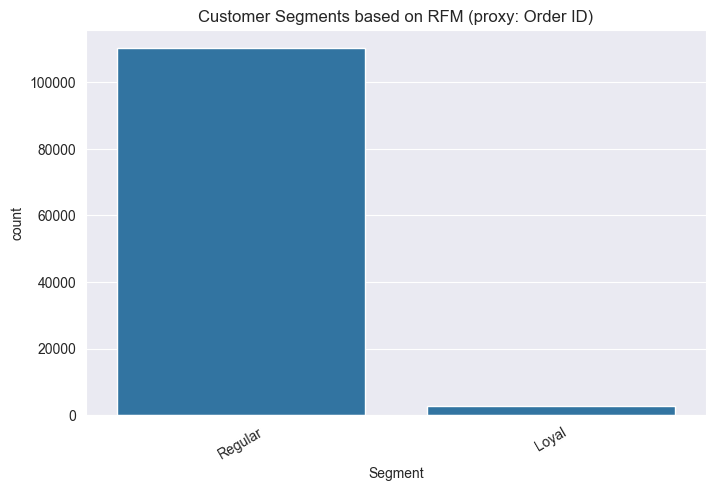

In [20]:
# Clean column names first
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# RFM Analysis using order_id as proxy for customer_id
df['date'] = pd.to_datetime(df['date'])
reference_date = df['date'].max() + pd.Timedelta(days=1)

# RFM Table
rfm = df.groupby('order_id').agg({
    'date': lambda x: (reference_date - x.max()).days,
    'order_id': 'count',  # Frequency: will always be 1 unless duplicate orders
    'amount': 'sum'
}).rename(columns={
    'date': 'Recency',
    'order_id': 'Frequency',
    'amount': 'Monetary'
}).reset_index()

# Scoring
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method="first"), 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Customer segment assignment
def segment_customer(row):
    if row['RFM_Score'] >= '444':
        return 'Loyal'
    elif row['R_Score'] == '4':
        return 'At Risk'
    elif row['F_Score'] == '1':
        return 'New/Low Value'
    else:
        return 'Regular'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x='Segment', data=rfm, order=rfm['Segment'].value_counts().index)
plt.title('Customer Segments based on RFM (proxy: Order ID)')
plt.xticks(rotation=30)
plt.show()


## 🌍 Geographical Sales Analysis

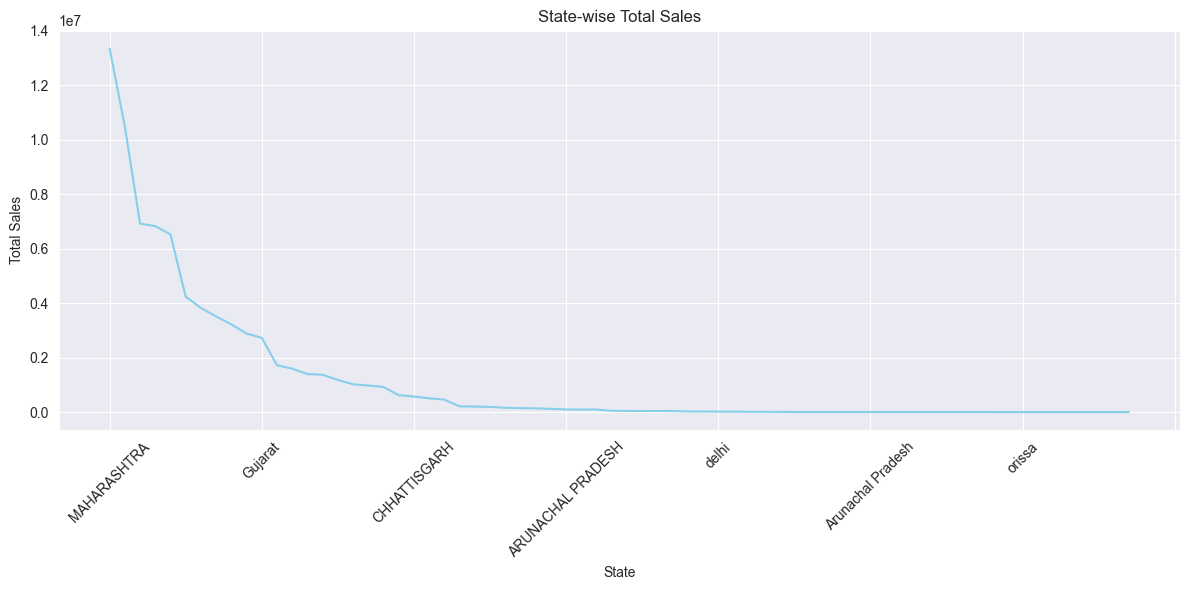

In [27]:
# Geographical Breakdown with corrected column name
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')

# Now this will work
state_sales = df.groupby('state')['amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
state_sales.plot(kind='line', color='skyblue')
#state_sales.plot(kind='bar', color='skyblue')

plt.title('State-wise Total Sales')
plt.xlabel('State')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [32]:
print(df.columns.tolist())


['order_id', 'date', 'status', 'fulfilment', 'sales_channel', 'ship_service_level', 'category', 'size', 'courier_status', 'quantity', 'currency', 'amount', 'city', 'state', 'ship_postal_code', 'country', 'b2b', 'fulfilled_by', 'month']


In [26]:
# 1. Peak month
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')
monthly_sales = df.groupby('month')['amount'].sum()
print("Peak Month:", monthly_sales.idxmax())

# 2. Top categories
print(df.groupby('category')['amount'].sum().sort_values(ascending=False).head(3))

# 3. Segment breakdown
print(rfm['Segment'].value_counts(normalize=True).mul(100).round(2))

# 4. Top states
print(df.groupby('state')['amount'].sum().sort_values(ascending=False).head(3))


Peak Month: 2022-04
category
T-shirt    39197808.65
Shirt      21289304.08
Blazzer    11214369.12
Name: amount, dtype: float64
Segment
Regular    97.63
Loyal       2.37
Name: proportion, dtype: float64
state
MAHARASHTRA    13340333.05
KARNATAKA      10480694.22
TELANGANA       6915018.08
Name: amount, dtype: float64


## 📈 Business Insights & Recommendations

### 🛒 Key Insights:
- Total sales peaked in **April 2022**, indicating a strong seasonal trend.
- The top-selling categories include **T-shirt, Shirt**, and **Blazzer**, contributing significantly to total revenue.
- Fulfillment via existing methods appears stable, but opportunities for optimization remain.
- Majority of sales come from **Maharashtra, Karnataka**, and **Telangana**, which can be targeted more in marketing.

### 🧠 Customer Segments:
- **Loyal customers**: 2.37%
- **Regular customers**: 97.63%

Targeted offers and loyalty programs can help increase the loyal customer base and improve retention.

### 🌍 Geographic Recommendations:
- High-potential states like **Telangana** show strong purchasing behavior and should be further targeted with promotions.
- Consider enhancing logistics and inventory in **Karnataka** and **Maharashtra** to support high demand and reduce fulfillment delays.

### ✅ Actionable Recommendations:
- Focus ad campaigns during the **March–May** window to leverage seasonal demand spikes.
- Prioritize inventory planning around top-selling products: **T-shirts, Shirts**, and **Blazzers**.
- Launch a loyalty incentive campaign to increase the proportion of **Loyal** customers from 2.37%.
- Expand logistics infrastructure and fulfillment support in **high-performing states** to improve customer satisfaction.
